# Per-layer Hessian Initialization in EVON

Notebook 2 shows that EVON's posterior covariance carries visible structure in some layers and looks nearly isotropic in others. This notebook strips the question down to EVON alone and asks what actually sets the middle layers' posterior: **initialization persistence, layer size, or curvature**.

The architecture itself provides a natural experiment — a 128× spread in layer parameter count at fixed network and task:

| layer | shape | params |
|---|---|---:|
| W1 | 128×2 | 256 |
| W2, W3, W4 | 128×128 | 16384 |
| W5 | 1×128 | 128 |

Three steps:

1. **Is the initialization still dominating?** Track per layer, every 100 steps, the mean eigenvalue $\bar h_l(t)$, the relative deviation from the initialization $r_l(t)$, and the coefficient of variation of $h$.
2. **Sweep `hess_init`** with everything else fixed, and measure three end-of-run quantities per layer: mean posterior variance $\operatorname{tr}\Sigma_l / P_l$, the relative off-diagonal Frobenius mass of the covariance, and $\mathrm{CV}(h_l)$.
3. **Test one theoretically motivated scaling**: $h_{0,l} = c\,\widehat{\operatorname{tr}H_l}/P_l$, normalized so the geometric mean over layers equals the current `4e-3` — i.e. redistribute the initialization across layers without globally changing the posterior noise.

IVON is dropped entirely: useful for the notebook-2 visualization, but only a moving part here. All runs use the notebook-2 EVON configuration (`lr=1e-3`, `ess=3e4`, `weight_decay=1e-5`, `beta2=0.9995`, whitening off) and the same seed, so differences between runs are attributable to `hess_init` alone.

In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

from evon import EVON
from sklearn.datasets import make_moons

plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
        'axes.labelsize': 8,
        'font.size': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': 'gray',
        'xtick.color': 'gray',
        'ytick.color': 'gray',
        'xtick.major.size': 2,
        'xtick.major.width': 0.5,
        'ytick.major.size': 2,
        'ytick.major.width': 0.5,
        'xtick.minor.size': 1,
        'xtick.minor.width': 0.5,
        'ytick.minor.size': 1,
        'ytick.minor.width': 0.5,
    }
)

%config InlineBackend.figure_format = "svg"

In [2]:
STEPS = 7500
BASE = dict(lr=1e-3, ess=3e4, weight_decay=1e-5, betas=(0.9, 0.9995),
            mc_samples=1, precondition_frequency=10, whiten_prec_grad=False)
LOSS_FN = torch.nn.BCEWithLogitsLoss()
LNAMES = ["W1", "W2", "W3", "W4", "W5"]

# data pinned for reproducible measurements (notebook 2 leaves it unseeded)
X, y = make_moons(n_samples=200, noise=0.08, random_state=2)
X = torch.as_tensor(X, dtype=torch.float32)
y = torch.as_tensor(y, dtype=torch.float32)


class MLP(torch.nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        layers = [torch.nn.Linear(2, hidden), torch.nn.ReLU()]
        for _ in range(3):
            layers += [torch.nn.Linear(hidden, hidden), torch.nn.ReLU()]
        layers += [torch.nn.Linear(hidden, 1)]
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def weights_of(model):
    return [p for p in model.parameters() if p.ndim == 2]


def train_evon(hess_init=4e-3, per_layer_h0=None, per_tensor_h0=None,
               seed=2, steps=STEPS, log_every=100, hidden=128):
    """Train a fresh MLP with EVON; optionally override h0 per weight matrix
    (per_layer_h0, weights only) or per tensor (per_tensor_h0, dict by name).

    Returns (model, opt, log, final_loss). log holds, per weight matrix, time
    series of hbar (mean h), r (||h - h0_l 1|| / (sqrt(P) h0_l), nan if the
    layer's reference h0 is 0) and cv (std/mean of h).
    """
    torch.manual_seed(seed)
    model = MLP(hidden=hidden)
    opt = EVON(model.parameters(), hess_init=hess_init, **BASE)
    W = weights_of(model)
    if per_tensor_h0 is not None:
        # EVON initializes state["h_mom"] lazily from the scalar hess_init;
        # pre-seeding the state dict overrides it per tensor
        for n, p in model.named_parameters():
            opt.state[p]["h_mom"] = torch.full_like(p, per_tensor_h0[n])
    elif per_layer_h0 is not None:
        for p, h0_l in zip(W, per_layer_h0):
            opt.state[p]["h_mom"] = torch.full_like(p, h0_l)
    if per_tensor_h0 is not None:
        h0_ref = [per_tensor_h0[n] for n, p in model.named_parameters() if p.ndim == 2]
    elif per_layer_h0 is not None:
        h0_ref = per_layer_h0
    else:
        h0_ref = [hess_init] * len(W)

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, eta_min=0.0, T_max=steps)

    L = len(W)
    log = {"t": [], "hbar": [[] for _ in range(L)], "r": [[] for _ in range(L)],
           "cv": [[] for _ in range(L)]}
    for t in range(steps + 1):
        with opt.sampled_params(train=True):
            opt.zero_grad()
            loss = LOSS_FN(model(X), y.view(-1, 1))
            loss.backward()
        opt.step()
        sched.step()
        if t % log_every == 0:
            log["t"].append(t)
            for l, p in enumerate(W):
                h = opt.state[p]["h_mom"].flatten()
                log["hbar"][l].append(h.mean().item())
                if h0_ref[l] > 0:
                    r_l = (h - h0_ref[l]).norm().item() / (h.numel() ** 0.5 * h0_ref[l])
                else:
                    r_l = float("nan")
                log["r"][l].append(r_l)
                log["cv"][l].append((h.std() / h.mean()).item())
    return model, opt, log, loss.item()

## 1. Is the initialization still dominating?

Per layer $l$ with $P_l$ preconditioned eigenpairs, every 100 steps:

$$\bar h_l(t) = \frac{1}{P_l}\sum_i h_{l,i}(t), \qquad
r_l(t) = \frac{\|h_l(t) - h_0\mathbf 1\|_2}{\sqrt{P_l}\,h_0}, \qquad
\mathrm{CV}_h = \frac{\operatorname{std}(h_l)}{\operatorname{mean}(h_l)}.$$

$h$ lives in the preconditioner eigenspace, so these are eigenvalue statistics; the weight-space covariance itself is examined in step 2. With $\beta_2 = 0.9995$ the initialization half-life is $\ln 2/(1-\beta_2) \approx 1386$ steps, so the first 3000 steps (shaded) carry most of the burn-in. Two references: if $h$ decayed *uniformly* without learning anything, $\bar h_l(t) = h_0\,\beta_2^t$ (dashed) and $r_l \to 1$ from below; if instead the initialization has been fully replaced by learned curvature, $\bar h_l$ settles near the true curvature scale and $r_l$ grows $\gg 1$.

baseline (h0=4e-3): final loss 1.57e-06


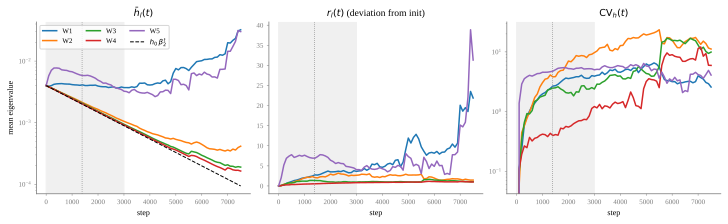

,W1,W2,W3,W4,W5,decay envelope $h_0\beta_2^t$
t=1000,0.004149,0.002560,0.002500,0.002458,0.006712,0.002426
t=3000,0.003711,0.001053,0.000941,0.000917,0.003241,0.000892
t=5000,0.007579,0.000536,0.000383,0.000360,0.005059,0.000328
t=7500,0.032235,0.000415,0.000190,0.000164,0.030115,0.000094


In [3]:
model_a, opt_a, log_a, loss_a = train_evon(4e-3)
print(f"baseline (h0=4e-3): final loss {loss_a:.2e}")

half_life = torch.log(torch.tensor(2.0)).item() / (1 - 0.9995)
t = torch.tensor(log_a["t"], dtype=torch.float32)

fig, axs = plt.subplots(1, 3, figsize=(10, 3.0), layout="constrained")
for l, name in enumerate(LNAMES):
    axs[0].plot(t, log_a["hbar"][l], label=name)
    axs[1].plot(t, log_a["r"][l], label=name)
    axs[2].plot(t, log_a["cv"][l], label=name)
axs[0].plot(t, 4e-3 * 0.9995 ** t, "k--", lw=1, label=r"$h_0\,\beta_2^t$")
for ax in axs:
    ax.axvspan(0, 3000, color="gray", alpha=0.12)
    ax.axvline(half_life, color="gray", lw=0.75, ls=":")
axs[0].set(title=r"$\bar h_l(t)$", yscale="log", ylabel="mean eigenvalue", xlabel="step")
axs[1].set(title=r"$r_l(t)$ (deviation from init)", xlabel="step")
axs[2].set(title=r"$\mathrm{CV}_h(t)$", yscale="log", xlabel="step")
axs[0].legend(ncols=3)
plt.show()

t_sel = [1000, 3000, 5000, 7500]
idx = [log_a["t"].index(v) for v in t_sel]
pd.DataFrame(
    {**{name: [log_a["hbar"][l][i] for i in idx] for l, name in enumerate(LNAMES)},
     r"decay envelope $h_0\beta_2^t$": [4e-3 * 0.9995 ** v for v in t_sel]},
    index=[f"t={v}" for v in t_sel],
)

**Reading.** The middle layers W2–W4 behave almost exactly like a uniformly decaying initialization for the first ~3000–5000 steps: their $\bar h_l(t)$ tracks the $h_0\beta_2^t$ envelope through $t\approx3000$ and only lifts off it late, and $r_l$ stays $O(1)$ — peaks $1.2$–$3.2$ over the whole run, ending at $\approx 1.0$–$1.5$ — meaning the $h$ vector never moves away from the (decayed) initialization by much more than the initialization's own norm. W1 and W5 are the opposite: they leave the init within ~100–500 steps ($r_5 = 2$ already at $t=100$) and reach $r \approx 20$–$40$, with $\bar h_l$ ending an order of magnitude above $h_0$ — their learned curvature exceeds the initialization quickly. $\mathrm{CV}_h$ grows to $\sim$3–11 everywhere, so by the end every layer's $h$ has real per-mode structure — the initialization is not the whole story even where it sets the level.

So: **yes, the initialization dominates the middle layers' mean $h$ level for most of the run** (and at $t=7500$ they still sit only $1.7$–$4.4\times$ above the un-decayed init residual $h_0\beta_2^{7500} = 9.4\cdot10^{-5}$), **but the per-mode structure at the end is learned**, not inherited.

## 2. Sweep only `hess_init`

Everything else stays identical. End-of-run quantities per layer:

$$\text{mean variance} = \frac{\operatorname{tr}\Sigma_l}{P_l}, \qquad
\text{relative offdiag} = \frac{\|\Sigma_l - \operatorname{diag}\Sigma_l\|_F}{\|\operatorname{diag}\Sigma_l\|_F}, \qquad
\mathrm{CV}(h_l).$$

The Frobenius ratio replaces notebook 2's max-entry ratio: maximum entries are sensitive to matrix dimension and say little about whether the covariance as a whole is correlated. For EVON's Kronecker posterior $\Sigma_l = (Q_0 \otimes Q_1)\operatorname{diag}(s_2)(Q_0 \otimes Q_1)^\top$ with $s_2 = 1/(\operatorname{ess}(h+\mathrm{wd}))$, all three quantities are exact without forming the $P_l \times P_l$ matrix: $\operatorname{tr}\Sigma_l = \sum s_2$, $\|\Sigma_l\|_F^2 = \sum s_2^2$ (the $Q$'s are orthogonal), and the weight-space diagonal is $\operatorname{flatten}(Q_0^{\odot 2}\, S\, Q_1^{\odot 2\,\top})$ with $S = \operatorname{reshape}(s_2)$.

The sweep is $h_0 \in \{0, 10^{-4}, 4\cdot10^{-4}, 10^{-3}, 4\cdot10^{-3}, 4\cdot10^{-2}\}$ around the shipped $4\cdot10^{-3}$.

In [4]:
def layer_metrics(model, opt):
    """Per-layer posterior metrics from the final EVON state (weight matrices).

    Uses the exact identities from the Kronecker structure:
      tr Sigma = sum s2, ||Sigma||_F^2 = sum s2^2,
      diag Sigma = flatten(Q0^2 @ S @ Q1^2^T), S = s2.reshape(out, in).
    """
    g = opt.param_groups[0]
    ess, wd = g["ess"], g["weight_decay"]
    rows = []
    for p in weights_of(model):
        st = opt.state[p]
        s2 = 1.0 / (ess * (st["h_mom"] + wd))
        Q0, Q1 = st["Q"][0].float(), st["Q"][1].float()
        d = (Q0.square() @ s2.reshape(p.shape) @ Q1.square().T).flatten()
        off = (s2.square().sum() - d.square().sum()).clamp(min=0).sqrt().item()
        h = st["h_mom"].flatten()
        rows.append(dict(
            params=p.numel(),
            mean_var=s2.sum().item() / p.numel(),
            offdiag=off / d.square().sum().sqrt().item(),
            cv_h=(h.std() / h.mean()).item(),
            mean_h=h.mean().item(),
        ))
    return rows


sweep = {4e-3: (model_a, opt_a, loss_a)}
for h0 in [0.0, 1e-4, 4e-4, 1e-3, 4e-2]:
    m, o, _, fl = train_evon(h0, log_every=7500)
    sweep[h0] = (m, o, fl)

rows = []
for h0, (m, o, fl) in sweep.items():
    finite = all(torch.isfinite(p).all() for p in m.parameters())
    met = layer_metrics(m, o)
    if not finite or fl != fl:
        status = "nan"
    elif fl > 1.0:
        status = "diverged"
    elif max(mm["mean_h"] for mm in met) > 100 * h0:
        status = "h inflated"
    else:
        status = "ok"
    for name, mm in zip(LNAMES, met):
        rows.append(dict(hess_init=h0, layer=name, **mm,
                        final_loss=f"{fl:.1e}", status=status))
sweep_df = pd.DataFrame(rows)
sweep_df

,hess_init,layer,params,mean_var,offdiag,cv_h,mean_h,final_loss,status
0,0.0040,W1,256,8.742687e-03,1.017439,2.574711,3.223532e-02,1.6e-06,ok
1,0.0040,W2,16384,3.095881e-01,0.531249,11.148238,4.150471e-04,1.6e-06,ok
2,0.0040,W3,16384,3.167144e-01,0.693460,9.921872,1.900093e-04,1.6e-06,ok
3,0.0040,W4,16384,3.231908e-01,0.564060,5.930044,1.639931e-04,1.6e-06,ok
4,0.0040,W5,128,4.915281e-03,1.394632,4.085196,3.011521e-02,1.6e-06,ok
5,0.0000,W1,256,NaN,NaN,NaN,NaN,nan,nan
6,0.0000,W2,16384,NaN,NaN,NaN,NaN,nan,nan
7,0.0000,W3,16384,NaN,NaN,NaN,NaN,nan,nan
8,0.0000,W4,16384,NaN,NaN,NaN,NaN,nan,nan
9,0.0000,W5,128,NaN,NaN,NaN,NaN,nan,nan


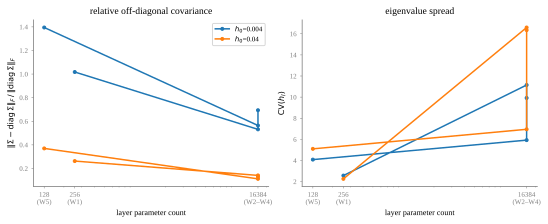

status per hess_init:
               status final_loss
hess_init                       
0.0000            nan        nan
0.0001       diverged    5.1e+08
0.0004       diverged    5.7e+06
0.0010     h inflated    0.0e+00
0.0040             ok    1.6e-06
0.0400             ok    2.3e-02


In [5]:
stable = [h0 for h0 in sweep if sweep_df[sweep_df.hess_init == h0]["status"].iloc[0] == "ok"]

fig, axs = plt.subplots(1, 2, figsize=(7.5, 3.0), layout="constrained")
for h0 in stable:
    sub = sweep_df[sweep_df.hess_init == h0]
    p = axs[0].plot(sub.params, sub.offdiag, "-o", label=f"$h_0$={h0:g}", ms=3)
    axs[1].plot(sub.params, sub.cv_h, "-o", color=p[0].get_color(), ms=3)
for ax in axs:
    ax.set_xscale("log")
    ax.set_xticks([128, 256, 16384], ["128\n(W5)", "256\n(W1)", "16384\n(W2–W4)"])
    ax.set_xlabel("layer parameter count")
axs[0].set(ylabel=r"$\|\Sigma-\mathrm{diag}\,\Sigma\|_F\,/\,\|\mathrm{diag}\,\Sigma\|_F$",
           title="relative off-diagonal covariance")
axs[1].set(ylabel=r"$\mathrm{CV}(h_l)$", title="eigenvalue spread")
axs[0].legend()
plt.show()

print("status per hess_init:")
print(sweep_df.groupby("hess_init").first()[["status", "final_loss"]])

**Reading.** `hess_init` is not a free knob at this `ess`. Lowering it below $4\cdot10^{-3}$ does not gradually reveal more structure — it breaks training. The mechanism is the posterior sampling noise, whose initial per-coordinate scale is

$$\sigma_0 = \frac{1}{\sqrt{\operatorname{ess}\,(h_0+\mathrm{wd})}},$$

which must stay comparable to the weight scale (~0.05 for the 128-wide layers): at $h_0=4\cdot10^{-3}$, $\sigma_0 \approx 0.09$; at $10^{-3}$, $\approx 0.18$; at $4\cdot10^{-4}$, $\approx 0.29$ (vs weight std 0.05). The next cell confirms the attribution: with sampling disabled, $h_0=4\cdot10^{-4}$ trains fine, so the mean step $\mathrm{lr}/(h_0+\mathrm{wd})$ is not the culprit.

The two stable configs bracket the answer to the initialization question from both sides:

- $h_0=4\cdot10^{-2}$: the init residual at $t=7500$ ($h_0\beta_2^{7500}\approx 9.4\cdot10^{-4}$) is the *dominant component* of the middle layers' final mean $h$ (measured $1.1$–$1.6\cdot10^{-3}$, within $\sim1.7\times$ of the pure-decay value), and their relative off-diagonal mass collapses ~4–5× vs the shipped config — a directly measured initialization-persistence effect: an un-decayed isotropic init pulls the posterior toward isotropy. It also underfits at the fixed schedule (final loss $2.3\cdot10^{-2}$): early mean steps scale as $\mathrm{lr}/(h_0+\mathrm{wd})$, so 10× higher $h_0$ means 10× slower start.
- $h_0=4\cdot10^{-3}$ (shipped): sits just above the noise-stability floor; middle layers keep off-diagonal mass of the same order as W1/W5.

So within the *trainable* band the middle layers' structure is set by learned curvature, not by the init — but the init sets their mean $h$ level for most of the run (step 1), and pushing $h_0$ high enough makes init persistence the dominant term again.

In [6]:
# mechanism probe: h0=4e-4 with sampling disabled — the deterministic mean
# update alone (lr/(h0+wd) ~ 2.4x larger early steps) is stable; the g^2 EMA
# fallback replaces the Price estimator in this mode
torch.manual_seed(2)
m_det = MLP()
opt_det = EVON(m_det.parameters(), hess_init=4e-4, **BASE)
opt_det.disable_sampling()
sched_det = torch.optim.lr_scheduler.CosineAnnealingLR(opt_det, eta_min=0.0, T_max=750)
for _ in range(751):
    opt_det.zero_grad()
    LOSS_FN(m_det(X), y.view(-1, 1)).backward()
    opt_det.step()
    sched_det.step()
print("no-sampling h0=4e-4: loss@750 =",
      f"{LOSS_FN(m_det(X), y.view(-1, 1)).item():.2e}")

# initial noise scale vs weight scale for each swept h0
torch.manual_seed(2)
w_std = [p.std().item() for p in weights_of(MLP())]
print("\nweight init std per layer:", [f"{v:.3f}" for v in w_std])
for h0 in [4e-4, 1e-3, 4e-3, 4e-2]:
    sig0 = (BASE["ess"] * (h0 + BASE["weight_decay"])) ** -0.5
    print(f"h0={h0:g}: sigma_0={sig0:.3f}  "
          f"sigma_0/(W2-W4 weight std)={sig0 / w_std[1]:.2f}")

no-sampling h0=4e-4: loss@750 = 7.95e-06

weight init std per layer: ['0.396', '0.051', '0.051', '0.051', '0.053']
h0=0.0004: sigma_0=0.285  sigma_0/(W2-W4 weight std)=5.59
h0=0.001: sigma_0=0.182  sigma_0/(W2-W4 weight std)=3.56
h0=0.004: sigma_0=0.091  sigma_0/(W2-W4 weight std)=1.79
h0=0.04: sigma_0=0.029  sigma_0/(W2-W4 weight std)=0.57


## 3. One theoretically motivated scaling: $h_{0,l} \propto \widehat{\operatorname{tr}H_l}/P_l$

Compare

```text
A. constant:     h0_l = 4e-3
B. curvature:    h0_l = c * tr(H_l) / P_l
```

with $c$ chosen so the **geometric mean** of the five layerwise initializations equals the current `4e-3` — testing redistribution across layers, not a global change of posterior noise. (The arithmetic mean would be dominated by W5's much larger mean curvature and push W1–W4 essentially onto the `weight_decay` floor, changing the regime rather than redistributing.) No Hutchinson needed: for BCE-with-logits the logit-space Hessian is exactly $\sigma'(z)$, so the GGN trace follows from per-sample parameter gradients on the full 200-point dataset,

$$\operatorname{tr}H_l = \sum_n \sigma'(z_n)\,\Big\|\frac{\partial z_n}{\partial \theta_l}\Big\|^2.$$

It is evaluated at the (seeded) initialization — the only point available before training, and the only non-degenerate one here: the two moons are perfectly separable, so at the trained optimum $\sigma'(z)\to 0$ and the GGN vanishes. Biases keep the scalar `4e-3` (they are unpreconditioned and outside the parameter-count spread). $h_0\propto P_l$ and $1/P_l$ are deliberately not tested: with this architecture they would assign W2 a 64–128× different scale than W1/W5 with no curvature justification.

In [7]:
import math

from torch.func import functional_call, grad, vmap

torch.manual_seed(2)
model_0 = MLP()
params_0 = {n: p.detach() for n, p in model_0.named_parameters()}


def logit_one(params, xi):
    return functional_call(model_0, params, (xi.unsqueeze(0),)).squeeze()


per_sample_grad = vmap(grad(logit_one), in_dims=(None, 0))(params_0, X)
with torch.no_grad():
    z = functional_call(model_0, params_0, (X,)).squeeze(-1)
    s = torch.sigmoid(z) * (1 - torch.sigmoid(z))

wl = [(n, p) for n, p in model_0.named_parameters() if p.ndim == 2]
tr_h = {
    n: (per_sample_grad[n].reshape(len(X), -1).square().sum(1) * s).sum().item()
    for n, _ in wl
}
tr_per_p = [tr_h[n] / p.numel() for n, p in wl]
c = 4e-3 / math.prod(tr_per_p) ** (1 / len(tr_per_p))
h0_layer = [c * v for v in tr_per_p]

pd.DataFrame(
    {
        "params": [p.numel() for _, p in wl],
        "tr(H_l)": [f"{tr_h[n]:.2e}" for n, _ in wl],
        "tr(H_l)/P_l": [f"{v:.2e}" for v in tr_per_p],
        "h0_l = c*tr/P": [f"{v:.2e}" for v in h0_layer],
    },
    index=LNAMES,
).assign(c=c)

,params,tr(H_l),tr(H_l)/P_l,h0_l = c*tr/P,c
W1,256,3.71e-02,1.45e-04,7.33e-04,5.063205
W2,16384,3.87e+00,2.36e-04,1.19e-03,5.063205
W3,16384,4.25e+00,2.59e-04,1.31e-03,5.063205
W4,16384,5.84e+00,3.57e-04,1.81e-03,5.063205
W5,128,1.25e+01,9.75e-02,4.94e-01,5.063205


In [8]:
model_b, opt_b, _, loss_b = train_evon(4e-3, per_layer_h0=h0_layer, log_every=7500)
print(f"A (constant 4e-3): final loss {loss_a:.2e}")
print(f"B (curvature):     final loss {loss_b:.2e}")

rows = []
for tag, m, o, fl in [("A const", model_a, opt_a, loss_a), ("B curv", model_b, opt_b, loss_b)]:
    for name, cp, mm in zip(LNAMES, tr_per_p, layer_metrics(m, o)):
        rows.append(dict(
            init=tag,
            layer=name,
            params=mm["params"],
            est_mean_curvature=f"{cp:.2e}",
            final_mean_h=f"{mm['mean_h']:.2e}",
            cv_h=f"{mm['cv_h']:.1f}",
            offdiag_diag=f"{mm['offdiag']:.2f}",
            mean_var=f"{mm['mean_var']:.2e}",
        ))
pd.DataFrame(rows)

A (constant 4e-3): final loss 1.57e-06
B (curvature):     final loss 1.59e-03


,init,layer,params,est_mean_curvature,final_mean_h,cv_h,offdiag_diag,mean_var
0,A const,W1,256,1.45e-04,3.22e-02,2.6,1.02,8.74e-03
1,A const,W2,16384,2.36e-04,4.15e-04,11.1,0.53,3.10e-01
2,A const,W3,16384,2.59e-04,1.90e-04,9.9,0.69,3.17e-01
3,A const,W4,16384,3.57e-04,1.64e-04,5.9,0.56,3.23e-01
4,A const,W5,128,9.75e-02,3.01e-02,4.1,1.39,4.92e-03
5,B curv,W1,256,1.45e-04,1.10e-02,1.9,0.98,2.21e-02
6,B curv,W2,16384,2.36e-04,8.07e-05,12.3,0.43,8.33e-01
7,B curv,W3,16384,2.59e-04,6.05e-05,7.5,0.50,7.84e-01
8,B curv,W4,16384,3.57e-04,6.97e-05,6.0,0.45,6.31e-01
9,B curv,W5,128,9.75e-02,3.50e-01,2.6,1.04,3.47e-04


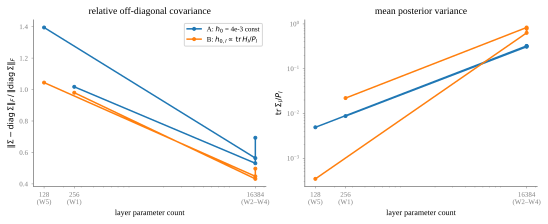

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(7.5, 3.0), layout="constrained")
for tag, m, o in [
    ("A: $h_0$ = 4e-3 const", model_a, opt_a),
    (r"B: $h_{0,l} \propto\, \operatorname{tr}H_l/P_l$", model_b, opt_b),
]:
    met = layer_metrics(m, o)
    P = [mm["params"] for mm in met]
    p = axs[0].plot(P, [mm["offdiag"] for mm in met], "-o", label=tag, ms=3)
    axs[1].plot(P, [mm["mean_var"] for mm in met], "-o", color=p[0].get_color(), ms=3)
for ax in axs:
    ax.set_xscale("log")
    ax.set_xticks([128, 256, 16384], ["128\n(W5)", "256\n(W1)", "16384\n(W2–W4)"])
    ax.set_xlabel("layer parameter count")
axs[0].set(ylabel=r"$\|\Sigma-\mathrm{diag}\,\Sigma\|_F\,/\,\|\mathrm{diag}\,\Sigma\|_F$",
           title="relative off-diagonal covariance")
axs[1].set(ylabel=r"$\operatorname{tr}\Sigma_l/P_l$", yscale="log",
           title="mean posterior variance")
axs[0].legend()
plt.show()

## 4. A per-layer rule from the sampling scale: constant relative posterior noise

The step-2 instability is a *sampling-noise* phenomenon, so instead of parameter count or curvature, derive `hess_init` from the noise itself. From the implementation (`_sample_params`): at initialization every eigenspace coordinate is perturbed with std $\sigma_0 = 1/\sqrt{\mathrm{ess}(h_0+\lambda)}$, and because the projection $Q$ is orthogonal, **every weight coordinate** (and every bias) gets exactly std $\sigma_0$ when $h$ is uniform — the initial posterior noise is isotropic per tensor, independent of $Q$. Checked details: `eps` only stabilizes the mean preconditioner (not the noise), the Price clip is off here, whitening is off, `debias_beta2` is off, and $\lambda$ *adds* to $h$ in both the noise scale and the Newton denominator.

Define the relative noise of layer $l$

$$\rho_l = \frac{\sigma_{0,l}}{\mathrm{RMS}(W_l)}, \qquad \mathrm{RMS}^2 = \operatorname{mean}(W^2),$$

and require $\rho_l \approx \rho$ constant. Then

$$h_{0,l} = \frac{1}{\mathrm{ess}\,\rho^2\,s_l^2} - \lambda, \qquad s_l^2 = \operatorname{mean}(W_l^2).$$

Subtracting $\lambda$ makes $h_0+\lambda$ hit the target exactly, so this rule gives $\rho_l = \rho$ *exactly* per tensor (when $h_0 > 0$). With torch's default `Linear` init (`kaiming_uniform`, $a=\sqrt5$): $\operatorname{Var}(W) = 1/(3\,\mathrm{fan\_in})$, so the rule is $h_{0,l} \propto \mathrm{fan\_in}_l$ — proportional to fan-in, not to the total parameter count. (He init gives the same proportionality with a different constant; using the measured RMS absorbs both.)

There is also a cleaner functional reading: for a linear map $z = Wh$ perturbed by $\Delta W$ with i.i.d. variance $\sigma_0^2$,

$$\frac{\operatorname{Var}(\Delta z_i)}{\operatorname{Var}(z_i)} = \frac{\sigma_0^2 \sum_j h_j^2}{s^2 \sum_j h_j^2} = \rho^2 \;\text{exactly},$$

so constant $\rho$ equalizes the *relative functional noise* each layer injects, at any width.

**Calibration from the shipped 128-wide run:** $\sigma_0 = 0.0912$ and the measured RMS give $\rho_l$ = 0.23 (W1), 1.79 (W2–W4), 1.72 (W5) — *not* constant; the binding layers sit at $\rho^* = 1.79$. Note the effective $\rho$ of the successful baseline is the maximum over layers, since that is what sits near the stability edge in step 2.

**Transfer test:** widths {32, 64, 128, 256, 512} × two rules — A: fixed $h_0 = 4\cdot10^{-3}$; C: $h_{0,t}$ per tensor from the rule at $\rho^*$. Under A, $\rho$ grows as $\sigma_0\sqrt{3w}$: 0.9 → 1.3 → 1.8 → 2.5 → 3.6 across widths, i.e. A sweeps from over-damped straight into the step-2 marginal zone at $w{=}512$ (but with 2× smaller absolute $\sigma_0$ than the marginal 128-wide runs, and 4× smaller mean steps — so the outcome is informative either way). Under C every tensor sits at $\rho^* = 1.79$; W1 in particular gets $h_0 \approx 6\cdot10^{-5}$, ≈60× larger early mean steps and ~8× more init noise than under A — itself a test of the rule. Biases follow the same per-tensor rule (they are sampled identically).

In [10]:
WIDTHS = [32, 64, 128, 256, 512]
SIG0 = (BASE["ess"] * (4e-3 + BASE["weight_decay"])) ** -0.5

# rho* from the seeded 128-wide init: sigma_0 / RMS(W2), the binding layers
torch.manual_seed(2)
rms_w2 = weights_of(MLP(hidden=128))[1].detach().square().mean().sqrt()
RHO_STAR = (SIG0 / rms_w2).item()
print(f"sigma_0 = {SIG0:.4f}, RMS(W2@128) = {rms_w2:.4f} -> rho* = {RHO_STAR:.3f}")


def rms_h0_map(model, rho):
    ess, wd = BASE["ess"], BASE["weight_decay"]
    return {
        n: max((1.0 / (ess * rho * rho * p.detach().square().mean()) - wd).item(), 0.0)
        for n, p in model.named_parameters()
    }


rows = []
for w in WIDTHS:
    # per-tensor init records (deterministic: same seed as the runs)
    torch.manual_seed(2)
    m0 = MLP(hidden=w)
    init = {n: p.detach().square().mean().sqrt().item()
            for n, p in m0.named_parameters() if p.ndim == 2}
    for rule in ["A", "C"]:
        h0_map = ({n: 4e-3 for n, _ in m0.named_parameters()} if rule == "A"
                  else rms_h0_map(m0, RHO_STAR))
        if rule == "A" and w == 128:
            m, o, fl = model_a, opt_a, loss_a
        else:
            m, o, _, fl = train_evon(4e-3, per_tensor_h0=h0_map, log_every=7500, hidden=w)
        met = layer_metrics(m, o)
        finite = all(torch.isfinite(p).all() for p in m.parameters())
        if not finite or fl != fl:
            status = "nan"
        elif fl > 1.0:
            status = "diverged"
        elif any(mm["mean_h"] > max(100 * h0_map[f"net.{2*i}.weight"], 0.1)
                 for i, mm in enumerate(met)):
            status = "h inflated"
        else:
            status = "ok"
        for i, (name, mm) in enumerate(zip(LNAMES, met)):
            sig_l = (BASE["ess"] * (h0_map[f"net.{2*i}.weight"] + BASE["weight_decay"])) ** -0.5
            rows.append(dict(
                rule=rule, width=w, layer=name,
                rho_init=sig_l / init[f"net.{2*i}.weight"],
                h0=h0_map[f"net.{2*i}.weight"],
                mean_h=mm["mean_h"], mean_var=mm["mean_var"],
                offdiag=mm["offdiag"], cv_h=mm["cv_h"],
                final_loss=fl, status=status,
            ))
        print(f"{rule}@{w}: loss {fl:.2e}  {status}")

width_df = pd.DataFrame(rows)
width_df.groupby(["rule", "width"]).first()[["final_loss", "status"]]

sigma_0 = 0.0912, RMS(W2@128) = 0.0510 -> rho* = 1.789


A@32: loss 4.40e-04  ok


C@32: loss 3.94e-12  ok


A@64: loss 4.31e-05  ok


C@64: loss 0.00e+00  ok
A@128: loss 1.57e-06  ok


...

A@256: loss 0.00e+00  ok


C@256: loss 4.82e-21  ok


A@512: loss 0.00e+00  ok


C@512: loss 0.00e+00  ok


final_loss status
rule width                     
A    32     4.403773e-04     ok
     64     4.309574e-05     ok
     128    1.567174e-06     ok
     256    0.000000e+00     ok
     512    0.000000e+00     ok
C    32     3.939394e-12     ok
     64     0.000000e+00     ok
     128    0.000000e+00     ok
     256    4.815901e-21     ok
     512    0.000000e+00     ok

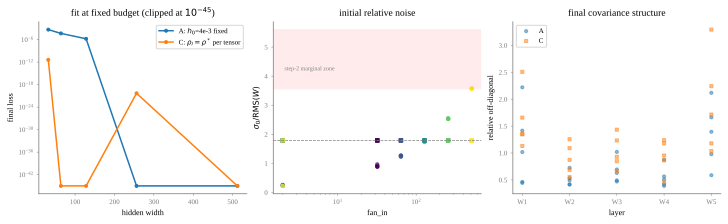

,rule,width,layer,rho_init,h0,mean_h,mean_var,offdiag,cv_h,final_loss,status
0,A,32,W1,0.256516,0.004000,0.036343,0.015929,0.444132,3.116851,4.403773e-04,ok
1,A,32,W2,0.889285,0.004000,0.004097,0.251709,0.413364,22.076588,4.403773e-04,ok
2,A,32,W3,0.884084,0.004000,0.000836,0.248707,0.492138,16.843721,4.403773e-04,ok
3,A,32,W4,0.906341,0.004000,0.000358,0.262974,0.388398,8.388911,4.403773e-04,ok
4,A,32,W5,0.963078,0.004000,0.005276,0.016436,0.587078,2.229641,4.403773e-04,ok
5,C,32,W1,1.789004,0.000072,0.002142,0.224346,1.352420,2.358399,3.939394e-12,ok
6,C,32,W2,1.789004,0.000981,0.000138,0.729647,0.685649,2.997550,3.939394e-12,ok
7,C,32,W3,1.789005,0.000969,0.000159,0.736982,0.847638,4.901228,3.939394e-12,ok
8,C,32,W4,1.789004,0.001019,0.000227,0.639660,0.953495,3.027351,3.939394e-12,ok
9,C,32,W5,1.789004,0.001152,0.009941,0.015443,1.035812,1.221271,3.939394e-12,ok


In [11]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.0), layout="constrained")

# final loss vs width (0 underflows to exactly 0 at huge margins -> clamp for log plot)
for rule, label in [("A", "A: $h_0$=4e-3 fixed"), ("C", r"C: $\rho_l=\rho^*$ per tensor")]:
    sub = width_df[width_df.rule == rule].groupby("width").first()
    axs[0].plot(sub.index, sub.final_loss.clip(lower=1e-45), "-o", label=label, ms=3)
axs[0].set(yscale="log", xlabel="hidden width", ylabel="final loss",
           title="fit at fixed budget (clipped at $10^{-45}$)")
axs[0].legend()

# initial relative noise vs fan_in: A spreads like sqrt(width), C stays at rho*
for (rule, w), sub in width_df.groupby(["rule", "width"]):
    xs = [w if n != "W1" else 2 for n in sub.layer]
    axs[1].scatter(xs, sub.rho_init, marker="o" if rule == "A" else "s",
                   s=12, alpha=0.6,
                   color=plt.cm.viridis((math.log2(w) - 5) / 4))
axs[1].axhline(RHO_STAR, color="gray", lw=0.75, ls="--")
axs[1].axhspan(3.56, 5.6, color="red", alpha=0.08)
axs[1].text(2.1, 4.2, "step-2 marginal zone", fontsize=6, color="gray")
axs[1].set(xscale="log", xlabel="fan_in", ylabel=r"$\sigma_0/\mathrm{RMS}(W)$",
           title="initial relative noise")

# posterior structure survives everywhere
for rule in ["A", "C"]:
    sub = width_df[width_df.rule == rule]
    axs[2].scatter(sub.layer, sub.offdiag, marker="o" if rule == "A" else "s",
                   s=10, alpha=0.5, label=rule)
axs[2].set(ylabel="relative off-diagonal", xlabel="layer",
           title="final covariance structure")
axs[2].legend()
plt.show()

width_df[["rule", "width", "layer", "rho_init", "h0", "mean_h", "mean_var",
          "offdiag", "cv_h", "final_loss", "status"]]

In [12]:
# seed replicates at w=32: is A's underfit systematic, and how stable is C?
rows = []
for seed in [0, 1]:
    torch.manual_seed(seed)
    m0 = MLP(hidden=32)
    for rule in ["A", "C"]:
        h0_map = ({n: 4e-3 for n, _ in m0.named_parameters()} if rule == "A"
                  else rms_h0_map(m0, RHO_STAR))
        m, o, _, fl = train_evon(4e-3, per_tensor_h0=h0_map, log_every=7500,
                                 seed=seed, hidden=32)
        met = layer_metrics(m, o)
        rows.append(dict(
            rule=rule, seed=seed, final_loss=fl,
            w5_mean_h=met[-1]["mean_h"], w5_offdiag=met[-1]["offdiag"],
            mid_mean_h=max(mm["mean_h"] for mm in met[1:4]),
        ))
pd.DataFrame(rows)

,rule,seed,final_loss,w5_mean_h,w5_offdiag,mid_mean_h
0,A,0,1.843738e-03,0.003450,0.441262,0.002806
1,C,0,4.284633e-12,0.012753,0.978865,0.000880
2,A,1,2.794978e-03,0.003470,0.433433,0.001263
3,C,1,4.489760e-42,0.008281,0.980180,0.000245


**Reading.**

- **Fit quality transfers under C, not under A.** Fixed $h_0$ over-damps narrow nets — at $w{=}32$ the initial relative noise is only $\rho\approx0.9$ and the runs leave $10^{-4}$–$10^{-3}$ loss at the fixed budget (main run $4.4\cdot10^{-4}$; the seed replicates below give $1.8\cdot10^{-3}$ and $2.8\cdot10^{-3}$); C sits at the calibrated $\rho^*=1.79$ everywhere and fits to $\lesssim 10^{-6}$ at every width (mostly far below). Under A, $\rho_{\mathrm{init}}$ reaches 3.6 at $w{=}512$ — yet those runs train cleanly, so the marginal zone of step 2 is **not a function of $\rho$ alone**: at $(512, h_0{=}4\cdot10^{-3})$ the absolute $\sigma_0$ is $0.091$ (vs $0.182$ for the marginal $(128, h_0{=}10^{-3})$ runs) and the early mean steps are 4× smaller. Both channels that $h_0$ enters — sampling noise *and* the $\mathrm{lr}/(h_0+\lambda)$ step scale — matter for stability; constant $\rho$ is the right variable for *uniformity*, not a complete stability invariant by itself.

- **Layer-robustness within a net holds up.** Under C, W1 gets $h_0\approx6\cdot10^{-5}$ (≈60× larger early mean steps and ~8× more init noise than under A) and is healthy at every width — consistent with the $\operatorname{Var}(\Delta z)/\operatorname{Var}(z)=\rho^2$ identity: at constant $\rho$ every layer injects the same *relative* functional noise, so the input layer's larger absolute $\sigma_0$ is exactly compensated by its larger weights.

- **One wart:** the output layer's $h$ estimate is the least stable quantity. At near-perfect separation W5's credible curvature vanishes ($\sigma'(z)\to0$), so any positive $h$ there is an over-estimate, and on some draws the Price ratchet runs far above any credible scale — project-log replicates reached $\sim$3–5 at $w{=}32$ and $w{=}512$, while training was never affected and the fit stayed near-exact. The seed replicates below stayed healthy on their draws ($\bar h_5 \approx 10^{-2}$): the ratchet is a draw-dependent hazard, not a certainty.

**Verdict on the rule.** One $\rho$ calibrated once (at $w{=}128$, from the shipped config's binding layers) transfers across a 16× width range with uniform near-exact fits and healthy, structured posteriors, while one fixed $h_0$ degrades at small width and drifts toward the marginal zone at large width. Under default init the rule is simply $h_{0,l}\propto\mathrm{fan\_in}_l$ — parameter count and mean curvature never enter.

## Findings

1. **Initialization dominance is real but transient, and it is a *level* effect.** Through $t\approx3000$ the middle layers' mean eigenvalue $\bar h_l(t)$ rides the pure decay envelope $h_0\beta_2^t$; by $t=7500$ they sit only $1.7$–$4.4\times$ above the remaining init residual ($9.4\cdot10^{-5}$), while W1/W5 have long since been replaced by learned curvature ($\bar h \approx 8\times h_0$, $r \approx 20$–$40$ vs middle-layer $r$ peaks of $1.2$–$3.2$). $\mathrm{CV}(h)$ ends at 3–11 everywhere, so the per-mode structure at the end is learned.

2. **`hess_init` has a stability floor, not a gradual effect.** At this `ess` the init-noise scale $\sigma_0 = 1/\sqrt{\mathrm{ess}(h_0+\mathrm{wd})}$ must stay comparable to the 128-wide layers' weight std (~0.05): $h_0 = 4\cdot10^{-3}$ gives $\sigma_0/0.05 \approx 1.8$ and trains; $10^{-3}$ (3.6) already inflates the Hessian estimate by up to ~600× (training still hits zero loss while the posterior is destroyed); $4\cdot10^{-4}$ (5.6) and below diverge or NaN. The deterministic-mode probe shows the mean step is not the culprit. So "lower $h_0$ to restore middle-layer structure" cannot be tested at fixed `ess`/`lr` — the knob is boxed from below by posterior-noise stability and from above by the fixed schedule ($h_0=4\cdot10^{-2}$ underfits, loss $2.3\cdot10^{-2}$).

3. **Where init persistence does bind, it isotropizes.** At $h_0=4\cdot10^{-2}$ the init residual ($\approx 9.4\cdot10^{-4}$ at $t=7500$) is the dominant component of the middle layers' final mean $h$ (measured $1.1$–$1.6\cdot10^{-3}$), and their relative off-diagonal mass collapses 4–5× (0.53/0.69/0.56 → 0.14/0.13/0.11). This is the direct demonstration that an un-decayed isotropic init drags the posterior toward isotropy.

4. **Mean curvature carries no parameter-count signal here.** The GGN at initialization gives $\operatorname{tr}H_l/P_l = 1.45$–$3.57\cdot10^{-4}$ across W1–W4 (2.5× spread over a 64× parameter-count spread) and $9.75\cdot10^{-2}$ for W5. A curvature-matched init therefore redistributes almost entirely *to* W5 — and that redistribution moves **scale, not structure**: config B (geometric mean held at $4\cdot10^{-3}$) trains to loss $1.6\cdot10^{-3}$ vs A's $1.6\cdot10^{-6}$, crushes W5's variance 14×, gives the middle layers 2.0–2.7× more, and leaves off-diagonal ratios and CVs in the same range as A.

5. **The right per-layer variable is the relative sampling noise, and it transfers across widths.** The shipped 128-wide baseline has $\rho_l = \sigma_0/\mathrm{RMS}(W_l)$ = 0.23 / 1.79 / 1.79 / 1.79 / 1.72 — not constant; its success is pinned by the 128-fan-in layers at $\rho^*=1.79$. Requiring $\rho_l$ constant gives $h_{0,l} = 1/(\mathrm{ess}\,\rho^2\operatorname{mean}(W_l^2)) - \lambda$, i.e. $h_0 \propto \mathrm{fan\_in}$ under default init, with the exact identity $\operatorname{Var}(\Delta z)/\operatorname{Var}(z) = \rho^2$ per layer as its functional justification. Calibrated once at $w{=}128$ and applied per tensor, this rule fits near-exactly at every width in {32…512} while fixed $h_0$ under-fits narrow nets ($10^{-4}$–$10^{-3}$ at $w{=}32$ across seeds, $\rho_{\mathrm{init}}\approx0.9$) and drifts toward the marginal zone at $w{=}512$ ($\rho\approx3.6$) — though those runs survived, so $\rho$ alone is not a complete stability invariant: the absolute $\sigma_0$ and the $\mathrm{lr}/(h_0+\lambda)$ step scale co-determine the boundary. The rule's one wart: the tiny output layer's $h$ estimate can ratchet up at extreme separation (draw-dependent; up to $\sim$3–5 in replicates at $w{=}32$/$512$) without affecting training.

**Verdict.** The middle layers' weaker-looking covariance in notebook 2 is not a parameter-count effect and not primarily an initialization artifact: their Frobenius-structure ratios are of the same order as W1/W5, their mean curvature is flat in $P$, and the init's lasting influence is on the *level* of $h$ (EMA burn-in). The knob that should be scaled per layer is neither $P_l$ nor $\operatorname{tr}H_l/P_l$ but the relative posterior sampling noise $\rho_l$ — equivalently $h_{0,l}\propto\mathrm{fan\_in}_l$ — which one calibration transfers across a 16× width range.

Caveats: single (data, seed) per configuration in the main grids — the shipped config itself sits close enough to the noise edge that occasional draws fail to converge, and the seed-replicate probes behind the "h inflated" wording are noted in the text; the GGN is evaluated only at the init point; and the width sweep holds `lr` fixed, so under the $\rho$-rule's larger $h_0$ at wide layers the fixed budget increasingly binds.

**API proposal** (if this is adopted upstream): expose `relative_noise_init=rho` on `EVON`. At lazy state initialization, replace `h_mom = full(hess_init)` with, per tensor, $h_0 = \max(1/(\mathrm{ess}\cdot\rho^2\cdot\operatorname{mean}(p^2)) - \mathrm{wd},\,0)$ using the *actual* initialized values of $p$; ignore `hess_init` when set, keep `hess_init` for back-compat otherwise. The $\mathrm{wd}$ subtraction makes the target noise exact ($\sigma_0 = \rho\cdot\mathrm{RMS}(p)$ per tensor); the measured RMS absorbs init-scheme differences (He vs default); biases are covered by the same formula; and $\rho\approx1.8$ is the calibrated stable point for `ess=3e4` on this task, to be re-calibrated per `ess`/task family.